In [14]:
# Dataset : https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
import pandas as pd
import seaborn as sns

In [16]:
df = pd.read_csv('./Dataset_custom/Cardiovascular_Disease_Dataset.csv')

In [17]:
df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [18]:
x = df.drop(["patientid", "target"], axis=1)
y = df["target"]

In [19]:
correlation = df.corr()

In [20]:
correlation

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
patientid,1.000000,0.004978,-0.031263,-0.009679,-0.020926,0.053464,0.022331,-0.003667,-0.036486,0.014338,-0.013825,-0.010128,0.019465,-0.005637
age,0.004978,1.000000,-0.024717,0.037731,-0.016126,0.035439,0.049732,0.067736,-0.040092,-0.037581,-0.026020,-0.015334,0.025407,0.008356
gender,-0.031263,-0.024717,1.000000,0.035402,-0.069727,-0.120759,0.023560,-0.046634,0.064606,-0.051746,0.331457,-0.051957,0.029376,0.015769
chestpain,-0.009679,0.037731,0.035402,1.000000,0.222267,0.174731,0.232059,0.256316,0.114496,-0.027376,0.101345,0.472731,0.285156,0.554228
restingBP,-0.020926,-0.016126,-0.069727,0.222267,1.000000,0.126523,0.192063,0.219887,0.095569,-0.046545,-0.004225,0.376711,0.263194,0.482387
serumcholestrol,0.053464,0.035439,-0.120759,0.174731,0.126523,1.000000,0.278337,0.101767,0.038967,0.029422,-0.025910,0.165569,0.132419,0.195340
fastingbloodsugar,0.022331,0.049732,0.023560,0.232059,0.192063,0.278337,1.000000,0.143982,0.096528,0.011356,0.015311,0.242734,0.182246,0.303233
restingrelectro,-0.003667,0.067736,-0.046634,0.256316,0.219887,0.101767,0.143982,1.000000,0.099991,-0.032489,0.040291,0.343280,0.204684,0.426837
maxheartrate,-0.036486,-0.040092,0.064606,0.114496,0.095569,0.038967,0.096528,0.099991,1.000000,0.015536,0.044614,0.201515,0.122763,0.228343
exerciseangia,0.014338,-0.037581,-0.051746,-0.027376,-0.046545,0.029422,0.011356,-0.032489,0.015536,1.000000,-0.003296,-0.017783,-0.017513,-0.039874


<Axes: >

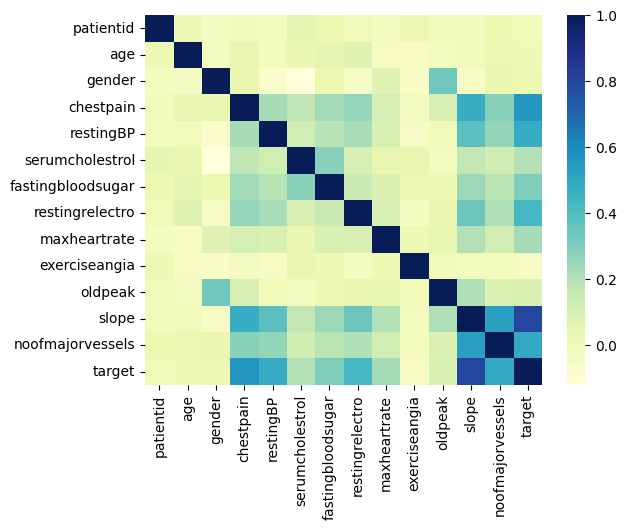

In [21]:
sns.heatmap(correlation, cmap='YlGnBu', vmax=1)

In [22]:
# sns.pairplot(df)

In [23]:
print(f"linear form shape: {x.shape}")

linear form shape: (1000, 12)


In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [25]:
model = Pipeline([
    ("add polynomial features", PolynomialFeatures(degree=2)),
    ("Normalization", StandardScaler()),
    ("model", LogisticRegression(penalty='l2'))
])

In [26]:
model.fit(x_train, y_train)

Pipeline(steps=[('add polynomial features', PolynomialFeatures()),
                ('Normalization', StandardScaler()),
                ('model', LogisticRegression())])

In [27]:
print(f"Polynomial form shape: {x_train.shape}")

Polynomial form shape: (700, 12)


In [28]:
train_accuracy, test_accuracy = model.score(x_test, y_test), model.score(x_train, y_train)
print(f"train_accuracy: {train_accuracy}\ntest_Accuracy: {test_accuracy}")

train_accuracy: 0.9833333333333333
test_Accuracy: 0.9814285714285714
